# Hemorrhage Detection

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Exploration and Visualization

In [3]:
DATASET_PATH = "/content/drive/MyDrive/hemorrhage_detect"

for cls in os.listdir(DATASET_PATH):

    class_path = os.path.join(
        DATASET_PATH,
        cls
    )

    print(
        f"{cls}:",
        len(os.listdir(class_path))
    )

no: 4407
yes: 8244


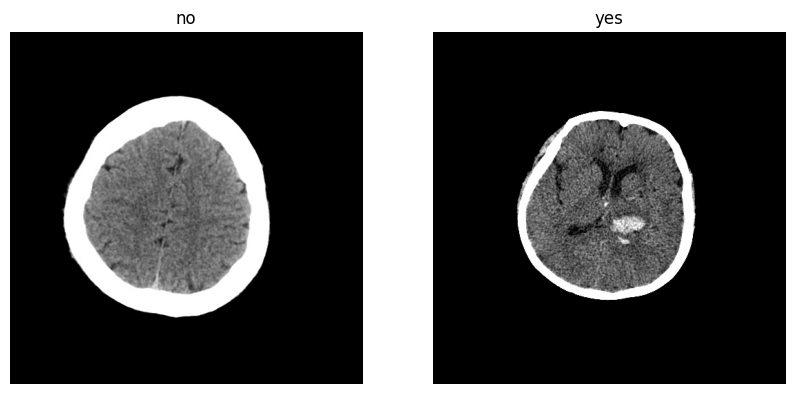

In [4]:
classes = os.listdir(DATASET_PATH)

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):

    class_path = os.path.join(
        DATASET_PATH,
        cls
    )

    image_file = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_file
    )

    img = Image.open(image_path)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.show()

In [5]:
for cls in os.listdir(DATASET_PATH):

    class_path = os.path.join(
        DATASET_PATH,
        cls
    )

    image_file = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_file
    )

    img = Image.open(image_path)

    print(cls)
    print("Size :", img.size)
    print("Mode :", img.mode)
    print()

no
Size : (512, 512)
Mode : L

yes
Size : (512, 512)
Mode : L



CLASS DISTRIBUTION

no                  : 4407
yes                 : 8244

Total Images: 12651


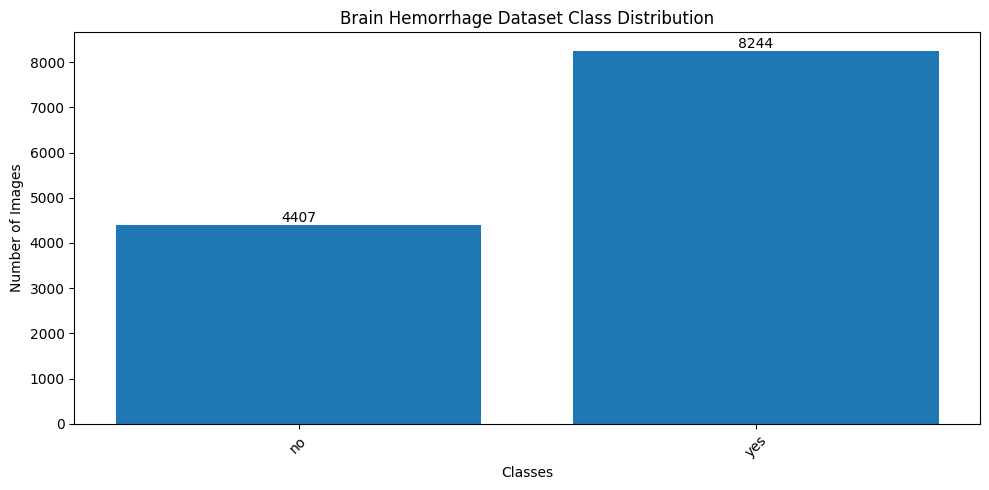

In [6]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = "/content/drive/MyDrive/hemorrhage_detect"

class_names = []
class_counts = []

print("CLASS DISTRIBUTION\n")

for cls in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(
        DATASET_PATH,
        cls
    )

    if os.path.isdir(class_path):

        count = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(
                os.path.join(class_path, f)
            )
        ])

        class_names.append(cls)
        class_counts.append(count)

        print(f"{cls:<20}: {count}")

print("\nTotal Images:", sum(class_counts))

plt.figure(figsize=(10,5))

bars = plt.bar(
    class_names,
    class_counts
)

plt.title(
    "Brain Hemorrhage Dataset Class Distribution"
)

plt.xlabel("Classes")
plt.ylabel("Number of Images")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Dataset Preprocessing

In [ ]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor()
])

In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

In [ ]:
print(dataset.classes)

print(dataset.class_to_idx)

print("Total Images:", len(dataset))


['no', 'yes']
{'no': 0, 'yes': 1}
Total Images: 12651


In [ ]:
image, label = dataset[0]

print(image.shape)

print(label)

torch.Size([3, 224, 224])
0


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

print("Train Images:", len(train_dataset))
print("Test Images :", len(test_dataset))

Train Images: 10120
Test Images : 2531


In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Model Loading , Training & Testing

In [ ]:
!cp -r "/content/drive/MyDrive/hemorrhage_detect" "/content/"

In [ ]:
DATASET_PATH = "/content/hemorrage_detect"

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 3, 224, 224])


In [ ]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
for param in model.parameters():
    param.requires_grad = False


In [ ]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        in_features=1280,
        out_features=2
    )
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(trainable_params)

2562


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

model = model.to(device)

cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [ ]:
model = model.to(device)

In [ ]:
num_epochs = 5

losses = [] # Initialize a list to store losses

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )
    losses.append(epoch_loss) # Append the epoch loss to the list

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0816
Epoch [2/5] Loss: 0.0777
Epoch [3/5] Loss: 0.0753
Epoch [4/5] Loss: 0.0707
Epoch [5/5] Loss: 0.0692


Text(0.5, 1.0, 'Training Loss')

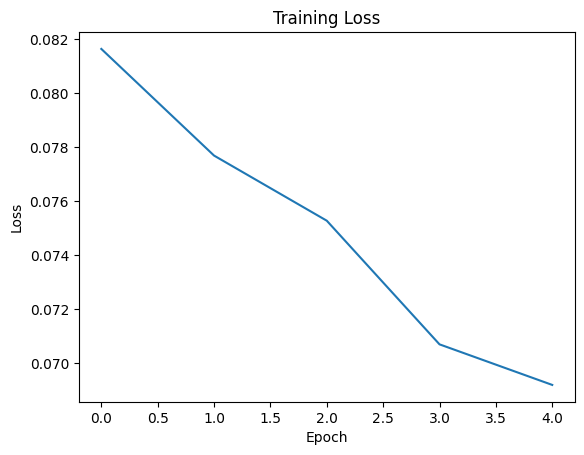

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = accuracy_score(
    all_labels,
    all_preds
)

print(
    f"Test Accuracy: {accuracy*100:.2f}%"
)

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:\n")
print(cm)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Normal",
            "Hemorrhage"
        ]
    )
)

Test Accuracy: 98.46%

Confusion Matrix:

[[ 895   20]
 [  19 1597]]

Classification Report:

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       915
  Hemorrhage       0.99      0.99      0.99      1616

    accuracy                           0.98      2531
   macro avg       0.98      0.98      0.98      2531
weighted avg       0.98      0.98      0.98      2531



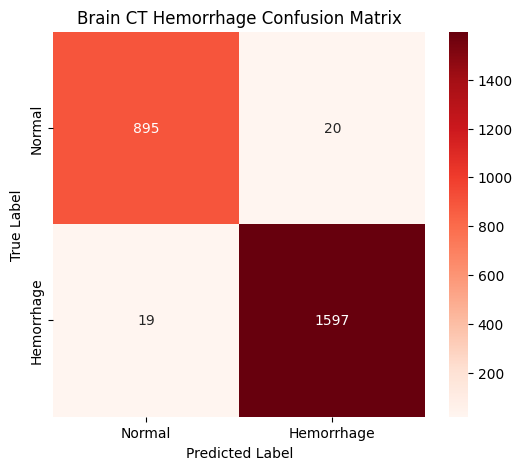

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[
        "Normal",
        "Hemorrhage"
    ],
    yticklabels=[
        "Normal",
        "Hemorrhage"
    ]
)

plt.title(
    "Brain CT Hemorrhage Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "brain_ct_model.pth"
)

In [ ]:
from google.colab import files
import torch
import torch.nn.functional as F
from torchvision import transforms

def upload_and_predict():

    uploaded = files.upload()

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    class_names = [
        "Normal",
        "Hemorrhage"
    ]

    model.eval()

    for filename in uploaded.keys():

        image = Image.open(filename)

        plt.figure(figsize=(5,5))
        plt.imshow(image, cmap="gray")
        plt.title(f"Uploaded Brain CT: {filename}")
        plt.axis("off")
        plt.show()

        image_tensor = transform(image)
        image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.to(device)

        with torch.no_grad():

            outputs = model(image_tensor)

            probs = F.softmax(
                outputs,
                dim=1
            )

            confidence, pred = torch.max(
                probs,
                dim=1
            )

        predicted_class = class_names[
            pred.item()
        ]

        print("\nPrediction :", predicted_class)

        print("\nClass Probabilities:\n")

        for idx, cls in enumerate(class_names):

            print(
                f"{cls:<12}: "
                f"{probs[0][idx].item()*100:.2f}%"
            )

        print(
            f"\nConfidence: "
            f"{confidence.item()*100:.2f}%"
        )


Saving h1.jpg to h1 (1).jpg


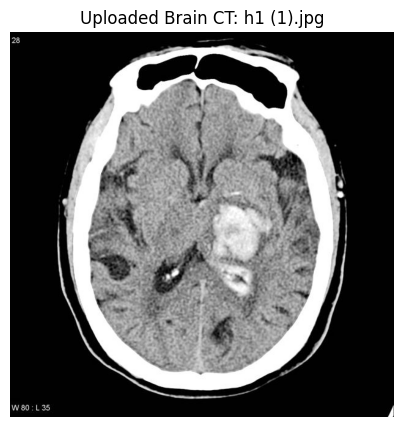


Prediction : Hemorrhage

Class Probabilities:

Normal      : 9.45%
Hemorrhage  : 90.55%

Confidence: 90.55%


In [ ]:
upload_and_predict()

Saving h5.jpg to h5 (1).jpg


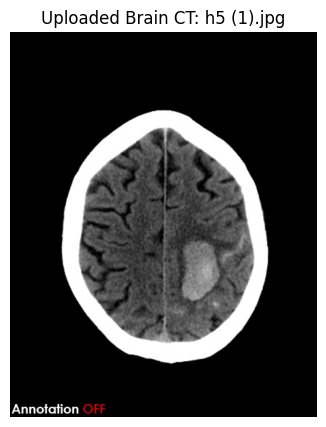


Prediction : Hemorrhage

Class Probabilities:

Normal      : 5.09%
Hemorrhage  : 94.91%

Confidence: 94.91%


In [ ]:
upload_and_predict()

Saving nh1.jpg to nh1.jpg


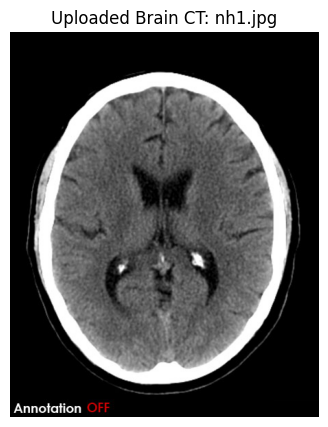


Prediction : Normal

Class Probabilities:

Normal      : 99.21%
Hemorrhage  : 0.79%

Confidence: 99.21%


In [ ]:
upload_and_predict()

Saving nh5.jpg to nh5 (1).jpg


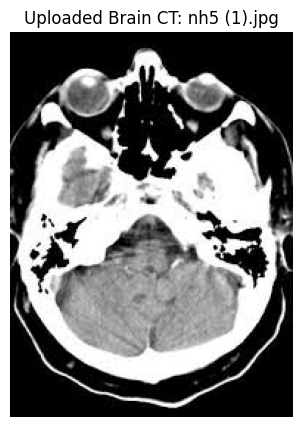


Prediction : Normal

Class Probabilities:

Normal      : 99.00%
Hemorrhage  : 1.00%

Confidence: 99.00%


In [ ]:
upload_and_predict()

# Grad Cam

In [ ]:
print(model.features)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [ ]:
target_layer = model.features[-1]

In [ ]:
import torch
import cv2
import numpy as np

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(
            self.save_activation
        )

        target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):
        self.activations = output

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):

        self.model.zero_grad()

        output = self.model(input_tensor)

        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(
            dim=(2,3),
            keepdim=True
        )

        cam = (
            weights * activations
        ).sum(dim=1)

        cam = torch.relu(cam)

        cam = cam.squeeze()

        cam = cam.detach().cpu().numpy()

        cam = cv2.resize(
            cam,
            (224,224)
        )

        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min() + 1e-8
        )

        return cam

In [ ]:
def visualize_gradcam():

    uploaded = files.upload()

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    target_layer = model.features[-1]

    gradcam = GradCAM(
        model,
        target_layer
    )

    class_names = [
        "Normal",
        "Hemorrhage"
    ]

    model.eval()

    for filename in uploaded.keys():

        image = Image.open(filename)

        original = image.convert("RGB")

        tensor = transform(image)

        input_tensor = (
            tensor.unsqueeze(0)
            .to(device)
        )
        input_tensor.requires_grad_(True) # Added this line

        output = model(input_tensor)

        probs = F.softmax(
            output,
            dim=1
        )

        pred = probs.argmax(
            dim=1
        ).item()

        confidence = (
            probs[0,pred].item()*100
        )

        cam = gradcam.generate(
            input_tensor,
            pred
        )

        img_np = np.array(
            original.resize((224,224))
        )

        heatmap = cv2.applyColorMap(
            np.uint8(cam*255),
            cv2.COLORMAP_JET
        )

        heatmap = cv2.cvtColor(
            heatmap,
            cv2.COLOR_BGR2RGB
        )

        overlay = (
            0.6*img_np +
            0.4*heatmap
        )

        overlay = np.uint8(
            overlay
        )

        plt.figure(
            figsize=(12,4)
        )

        plt.subplot(1,3,1)
        plt.imshow(img_np)
        plt.title("Original CT")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(cam,
                   cmap="jet")
        plt.title("Grad-CAM")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

        plt.show()

        print(
            f"Prediction: {class_names[pred]}"
        )

        print(
            f"Confidence: {confidence:.2f}%"
        )

Saving h3.jpg to h3 (2).jpg


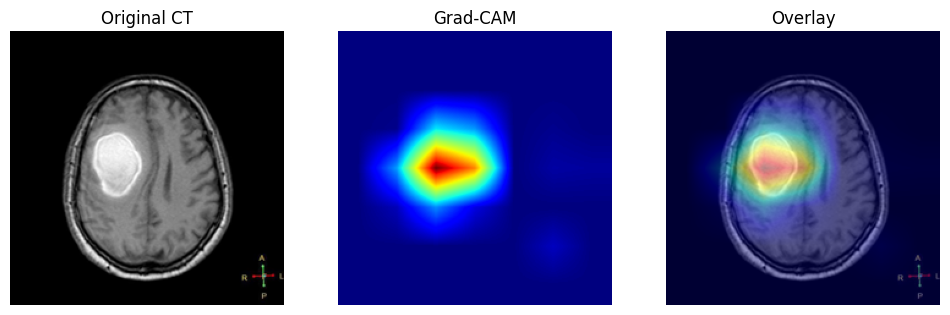

Prediction: Hemorrhage
Confidence: 70.72%


In [ ]:
visualize_gradcam()

Saving nh4.jpg to nh4 (2).jpg


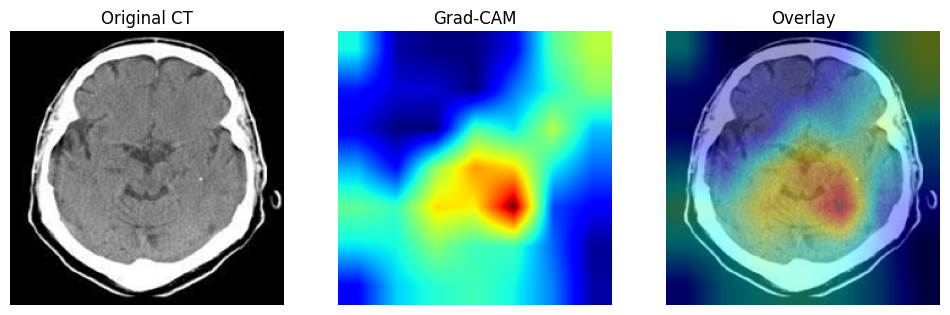

Prediction: Normal
Confidence: 99.31%


In [ ]:
visualize_gradcam()

In [ ]:
torch.save(model.state_dict(), "brain_ct_hemorrhage.pth")

In [ ]:
from google.colab import files
files.download("brain_ct_hemorrhage.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>